#Final Case Study: Netflix Dataset

###**1. Data Loading & Overview. Load the CSV into a DataFrame. What are its dimensions (.shape )? Display the first and last five rows. What insights do you immediately notice about the columns?**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Load the CSV into a DataFrame
import pandas as pd
NETFLIX = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/netflix_titles.csv')

In [ ]:
# What are its dimensions
NETFLIX.shape

(8807, 12)

Display the first and last five rows

In [ ]:
NETFLIX.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
NETFLIX.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


What insights do you immediately notice about the columns?____________



###**2. Data Cleaning. Which columns contain missing values? How might you handle missing entries? Drop them or fill with a placeholder?**

In [ ]:
# Which columns contain missing values?

NETFLIX[['show_id', 'type', 'title', 'director', 'cast', 'country',
          'date_added', 'release_year', 'rating', 'duration',
          'listed_in', 'description']].isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


 How might you handle missing entries?_______

In [ ]:
# Drop them or fill with a placeholder?

NETFLIX['director'] = NETFLIX['director'].fillna('Unknown')
NETFLIX['cast'] = NETFLIX['cast'].fillna('Unknown')
NETFLIX['country'] = NETFLIX['country'].fillna('Unknown')
NETFLIX['date_added'] = NETFLIX['date_added'].fillna('Unknown')
NETFLIX['rating'] = NETFLIX['rating'].fillna('Unknown')
NETFLIX['duration'] = NETFLIX['duration'].fillna('Unknown')


###**3. Data Types & Conversion. Check each column's data type. Are there any that you need to convert (like date to datetime type)?**

In [ ]:
NETFLIX['date_added'] = pd.to_datetime(NETFLIX['date_added'], errors='coerce')

# 1. Convert dtypes to a table format
dtypes_df = NETFLIX.dtypes.reset_index()
dtypes_df.columns = ['Column', 'Data Type']

# Displaying the table
dtypes_df

,Column,Data Type
0,show_id,object
1,type,object
2,title,object
3,director,object
4,cast,object
5,country,object
6,date_added,datetime64[ns]
7,release_year,int64
8,rating,category
9,duration,object


###**4. Univariate Analysis. How many Movies vs. TV Shows are there? What are the top five most common ratings? Which release year appears most frequently?**

In [ ]:
# 1. Calculate the counts
type_counts = NETFLIX['type'].value_counts().reset_index()
top_ratings = NETFLIX['rating'].value_counts().head(5).reset_index()
most_common_release_year = NETFLIX['release_year'].mode()[0]

# 2. Display them as tables
print("Movies vs TV Shows:")
display(type_counts)

print("\nTop 5 Ratings:")
display(top_ratings)

print(f"\nMost Common Release Year: {most_common_release_year}")

Movies vs TV Shows:


,type,count
0,Movie,6131
1,TV Show,2676



Top 5 Ratings:


,rating,count
0,TV-MA,3207
1,TV-14,2160
2,TV-PG,863
3,R,799
4,PG-13,490



Most Common Release Year: 2018


### **5. Duration & Seasons. Parse duration into numeric minutes (for movies) and number of seasons (for shows). What is the average movie length? The average number of seasons per TV show?**

In [ ]:
#Parse duration into numeric minutes (for movies) and number of seasons (for shows).

NETFLIX['duration_num'] = NETFLIX['duration'].str.extract(r'(\d+)').astype(float)

In [ ]:
# What is the average movie length?
# and The average number of seasons per TV show?

# average for Movies only
avg_movie_mins = NETFLIX[NETFLIX['type'] == 'Movie']['duration_num'].mean()

# average for TV Shows only
avg_tv_seasons = NETFLIX[NETFLIX['type'] == 'TV Show']['duration_num'].mean()

print(f"Average Movie Duration: {avg_movie_mins:.2f} minutes")
print(f"Average TV Show Length: {avg_tv_seasons:.2f} seasons")

Average Movie Duration: 99.58 minutes
Average TV Show Length: 1.76 seasons


### **6. Genre Analysis. Which genre has the highest average release year? What might that indicate?**

In [ ]:

# Select relevant columns and drop rows with missing genres
NETFLIX_genres = (
    NETFLIX[['title', 'release_year', 'listed_in']]
    .dropna(subset=['listed_in'])
    .copy()
)

# Split genre strings and explode into separate rows
NETFLIX_genres_exploded = (
    NETFLIX_genres
    .assign(genre=NETFLIX_genres['listed_in'].str.split(','))
    .explode('genre')
)

# Clean whitespace
NETFLIX_genres_exploded['genre'] = NETFLIX_genres_exploded['genre'].str.strip()

# Compute average release year per genre (TABLE format)
genre_avg_year_table = (
    NETFLIX_genres_exploded
    .dropna(subset=['release_year'])
    .groupby('genre')
    .agg(avg_release_year=('release_year', 'mean'))
    .reset_index()  # <-- KEY FIX: turn index into column
    .sort_values(by='avg_release_year', ascending=False)
)

high = 10
genre_avg_year_table.head(high)



,genre,avg_release_year
36,TV Mysteries,2018.346939
35,TV Horror,2018.200000
23,Reality TV,2017.894118
31,Stand-Up Comedy & Talk Shows,2017.857143
39,TV Thrillers,2017.736842
8,Crime TV Shows,2017.687234
28,Spanish-Language TV Shows,2017.477011
32,TV Action & Adventure,2017.404762
11,Docuseries,2017.232911
34,TV Dramas,2017.190039


7. Temporal Trends. Are there spikes or drops? Compare release_year VS. year_added :
how long after release does Netflix typically acquire content?

Mean acquisition lag (years): 4.7004025301897645
Median acquisition lag (years): 1.0


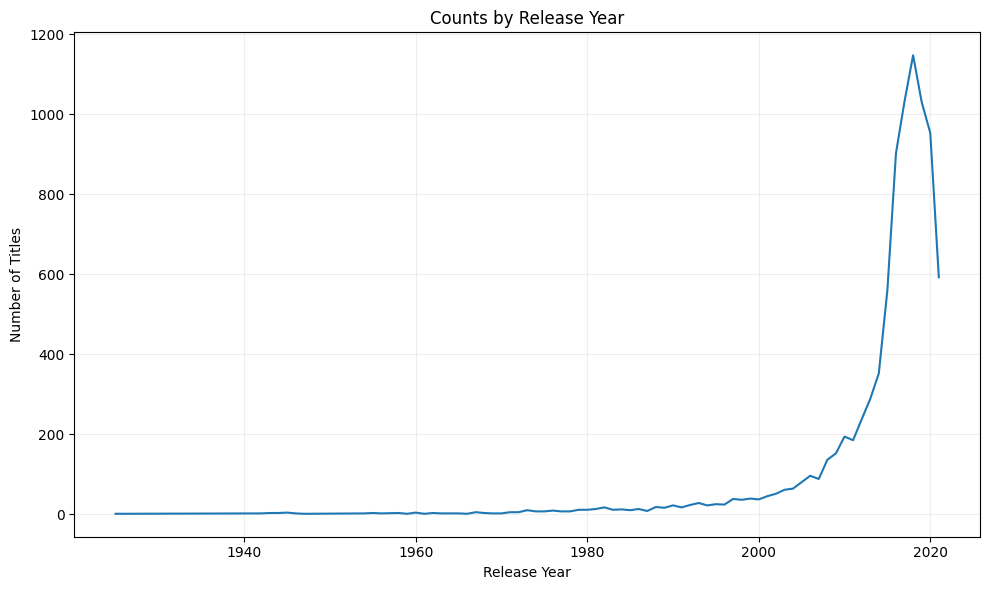

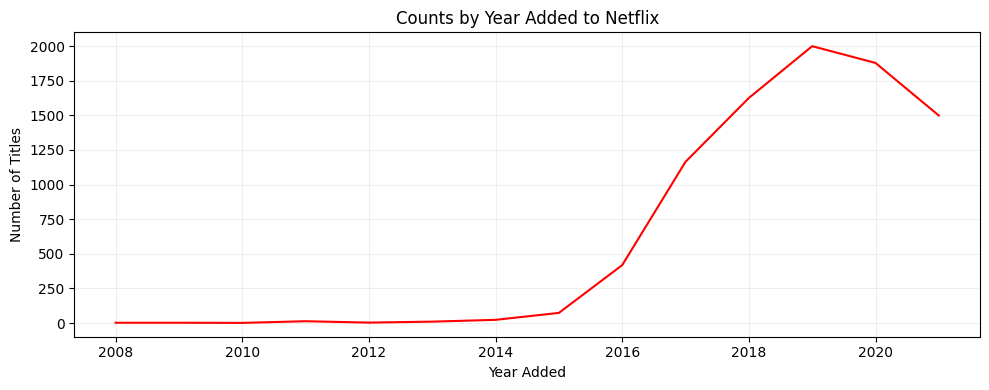

In [ ]:

# 1. CLEANING THE DATES
# Convert 'date_added' to actual datetime objects
# 'coerce' ensures that if a date is weird/unreadable, it becomes a blank (NaT) instead of an error
NETFLIX['date_added'] = pd.to_datetime(NETFLIX['date_added'], errors='coerce')

# Extract just the year (e.g., 2021) into a new column
NETFLIX['year_added'] = NETFLIX['date_added'].dt.year


# 2. CALCULATING THE TIME GAP (LAG)
# Find how many years passed between the movie's release and its arrival on Netflix
NETFLIX['acquisition_lag_years'] = NETFLIX['year_added'] - NETFLIX['release_year']

# Remove rows with errors (like movies added before they were even released)
# We keep only years between 0 and 100
mask = (NETFLIX['acquisition_lag_years'] >= 0) & (NETFLIX['acquisition_lag_years'] <= 100)
lag_clean = NETFLIX[mask]

# Print the averages
print("Mean acquisition lag (years):", lag_clean['acquisition_lag_years'].mean())
print("Median acquisition lag (years):", lag_clean['acquisition_lag_years'].median())


# 3. PLOT 1: TREND BY RELEASE YEAR
# Count movies per release year and sort them chronologically
release_counts = NETFLIX['release_year'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
plt.plot(release_counts.index, release_counts.values)
plt.title('Counts by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('release_year_timeseries.png')
plt.show()


# 4. PLOT 2: TREND BY YEAR ADDED TO NETFLIX
# Count movies added each year (ignoring blanks)
added_counts = NETFLIX['year_added'].dropna().astype(int).value_counts().sort_index()

plt.figure(figsize=(10, 4))
plt.plot(added_counts.index, added_counts.values, color='red')
plt.title('Counts by Year Added to Netflix')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('year_added_timeseries.png')
plt.show()

8. Rating vs. Type. Create a cross-tab or pivot table of type vs. rating.
Which rating dominates movies compared to TV shows?

In [ ]:
import pandas as pd

data = {
    'title': ['Red Notice', 'Bird Box', 'Extraction', 'Stranger Things', 'The Crown', 'Money Heist'],
    'type': ['Movie', 'Movie', 'Movie', 'TV Show', 'TV Show', 'TV Show'],
    'rating': ['PG-13', 'R', 'R', 'TV-14', 'TV-MA', 'TV-MA']
}

df = pd.DataFrame(data)

crosstab = pd.crosstab(df['type'], df['rating'])

print("Cross-tab (Type vs Rating):")
print(crosstab)

Cross-tab (Type vs Rating):
rating   PG-13  R  TV-14  TV-MA
type                           
Movie        1  2      0      0
TV Show      0  0      1      2


9. Filtering & Querying. Extract all titles with rating "R" added after 2020. How many?

In [ ]:
import pandas as pd

data = {
    'title': ['Red Notice', 'Bird Box', 'Extraction', 'The Irishman', 'Army of the Dead'],
    'rating': ['PG-13', 'R', 'R', 'R', 'R'],
    'date_added': [
        'November 12, 2021',
        'December 21, 2018',
        'April 24, 2020',
        'November 27, 2019',
        'May 21, 2021'
    ]
}

df = pd.DataFrame(data)


df['date_added'] = pd.to_datetime(df['date_added'])


df['year_added'] = df['date_added'].dt.year


filtered = df[(df['rating'] == 'R') & (df['year_added'] > 2020)]


count = len(filtered)

print("Filtered Titles:")
print(filtered[['title', 'rating', 'year_added']])
print("\nTotal count:", count)

Filtered Titles:
              title rating  year_added
4  Army of the Dead      R        2021

Total count: 1


10. Aggregations & GroupBy. For each country, compute the average release year of its titles.
Group by year_added and compute the proportion of Movies vs. TV Shows added
each year.



In [ ]:
import pandas as pd

data = {
    'title': ['Red Notice', 'Bird Box', 'Extraction'],
    'country': ['United States', 'United States', 'United States'],
    'release_year': [2021, 2018, 2020],
    'type': ['Movie', 'Movie', 'Movie'],
    'date_added': ['November 12, 2021', 'December 21, 2018', 'April 24, 2020']
}

df = pd.DataFrame(data)

print("Netflix Movies Dataset:")
print(df)

Netflix Movies Dataset:
        title        country  release_year   type         date_added
0  Red Notice  United States          2021  Movie  November 12, 2021
1    Bird Box  United States          2018  Movie  December 21, 2018
2  Extraction  United States          2020  Movie     April 24, 2020


Objectives.


1. Compute the average release year per country

2. Analyze content trends over time by finding the proportion of Movies vs TV Shows added each ye

11. Applying Functions. Write a function that, given a director's name, returns their titles sorted by release_year .
Create a reusable function to plot the top N categories for any categorical column.

Movies by Martin Scorsese:
          title  release_year
4  The Irishman          2019


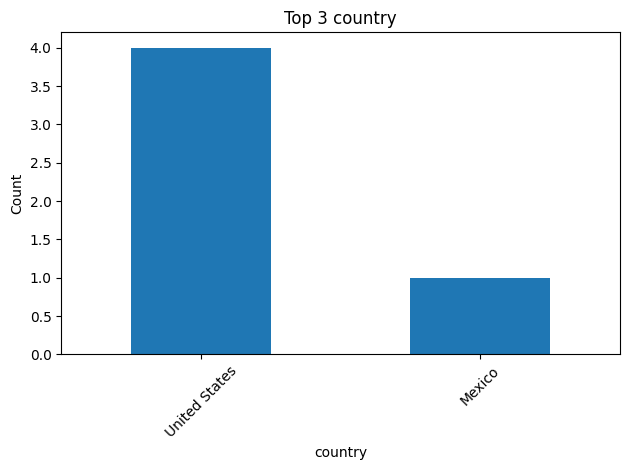

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    'title': ['Red Notice', 'Bird Box', 'Extraction', 'Roma', 'The Irishman'],
    'director': ['Rawson Marshall Thurber', 'Susanne Bier', 'Sam Hargrave', 'Alfonso Cuarón', 'Martin Scorsese'],
    'release_year': [2021, 2018, 2020, 2018, 2019],
    'type': ['Movie', 'Movie', 'Movie', 'Movie', 'Movie'],
    'country': ['United States', 'United States', 'United States', 'Mexico', 'United States']
}

df = pd.DataFrame(data)

def get_titles_by_director(df, director_name):
    result = df[df['director'] == director_name]
    result = result.sort_values(by='release_year')
    return result[['title', 'release_year']]

def plot_top_n(df, column, n=5):
    counts = df[column].value_counts().head(n)

    counts.plot(kind='bar')
    plt.title(f"Top {n} {column}")
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


print("Movies by Martin Scorsese:")
print(get_titles_by_director(df, 'Martin Scorsese'))

plot_top_n(df, 'country', 3)

Objectives


1.Create a function that returns all titles by a given director, sorted by release year


2.Create a reusable function to plot the top N categories for any categorical column